In [1]:
import numpy as np
import pymap3d as pm
from scipy.interpolate import CubicHermiteSpline
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import os
import csv


In [2]:
class Waypoint:
    def __init__(self, lat, lon, alt, speed, heading_deg):
        self.lat = lat
        self.lon = lon
        self.alt = alt
        self.speed = speed
        self.heading_deg = heading_deg

In [3]:
class flightpath_csv:
    def __init__(self):
        self.data = ['time (s)', 'x_pos (m)', 'y_pos (m)', 'z_pos (m)',
                      'x_vel (m/s)', 'y_vel (m/s)', 'z_vel (m/s)',
                      'yaw (deg)', 'pitch (deg)', 'roll (deg)']
        
    def csv_saver(self, data, filename=None, directory=None):

        
        # --- Note: I added velocity and orientationplots just to add another visual for doublechecking ---
        # --- I don't think the orientation calculations are correct because they translate directly from the interpolated velocity ---

        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

        ax1.plot(data[:, 0], data[:, 4], label='X Velocity')
        ax1.plot(data[:, 0], data[:, 5], label='Y Velocity')
        ax1.plot(data[:, 0], data[:, 6], label='Z Velocity')
        ax1.plot(data[:, 0], np.linalg.norm(data[:, 4:7], axis=1), label='Total Velocity', linestyle='--', color='black')
        ax1.set_ylabel('Velocity (m/s)')
        ax1.set_title('Flight Path Velocities')
        ax1.legend()

        ax2.plot(data[:, 0], data[:, 7], label='Yaw', color='tab:orange')
        ax2.plot(data[:, 0], data[:, 8], label='Pitch', color='tab:purple')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Angle (deg)')
        ax2.set_title('Yaw and Pitch Over Time')
        ax2.legend()

        fig.tight_layout()

        output_path = os.path.join(directory, filename)
        os.makedirs(directory, exist_ok=True)
        np.savetxt(output_path, data, delimiter=',', header=','.join(self.data), comments='')
        return output_path

In [ ]:
def interpolate(waypoints):
    wp_ecef = np.array([pm.geodetic2ecef(wp.lat, wp.lon, wp.alt) for wp in waypoints])
 
    t = [0.0]
    for i in range(1, len(waypoints)):
        dist = np.linalg.norm(wp_ecef[i] - wp_ecef[i - 1])
        avg_speed = (waypoints[i].speed + waypoints[i - 1].speed) / 2.0
        t.append(t[-1] + dist / avg_speed)
    t = np.array(t)
 
    vel = np.array([pm.enu2uvw(wp.speed * np.sin(np.radians(wp.heading_deg)),
            wp.speed * np.cos(np.radians(wp.heading_deg)), 0.0, wp.lat, wp.lon) for wp in waypoints])
 
    spline = CubicHermiteSpline(t, wp_ecef, vel, axis=0)

    sample_rate = 10.0
    dt = 1.0 / sample_rate
    t_array = np.arange(t[0], t[-1] + (dt / 2.0), dt)
    pos_array = spline(t_array)
    vel_array = spline.derivative()(t_array)

    lat_pos, lon_pos, _ = pm.ecef2geodetic(pos_array[:, 0], pos_array[:, 1], pos_array[:, 2])
    vE, vN, vU = pm.uvw2enu(vel_array[:, 0], vel_array[:, 1], vel_array[:, 2], lat_pos, lon_pos)

    # --- Yaw convention: heading clockwise from north, wrapped to [0, 360) ---
    yaw_array = (np.degrees(np.arctan2(vE, vN)) + 360.0) % 360.0
    horizontal_speed = np.hypot(vE, vN)
    pitch_array = np.degrees(np.arctan2(vU, horizontal_speed))

    # --- Roll isn't calculated here and is set to zero ---
    roll_array = np.zeros_like(yaw_array)

    # --- Saving the data to one array ---

    interp_data = np.column_stack((
    t_array,
    pos_array[:, 0],
    pos_array[:, 1],
    pos_array[:, 2],
    vel_array[:, 0],
    vel_array[:, 1],
    vel_array[:, 2],
    yaw_array,
    pitch_array,
    roll_array,))

    return interp_data

In [14]:
# --- Note: all of these functions are all based on relative positions to a reference point as defined in __init__ ---

class pre_made_flightpaths:
    def __init__(self):
        # --- Reference position of object for other calculations ---
        self.ref_pos = [0, 0, 0] # LLA
        self.sample_rate = 10.0 # in Hz

    def const_alt_inline(self):
        status = False
        
    def const_alt_offset(self):
        status = False

    def const_range_alt(self):
        status = False

    def const_range_el(self, slant_range=None, el=None, az_i=None, az_f=None, true_vel=None, orientation=None, banking=None):
        
        range = slant_range * np.cos(np.radians(el))

        if orientation == 'cw':
            ang_vel = np.degrees(true_vel / range) # degrees/s
        elif orientation == 'ccw':
            ang_vel = -np.degrees(true_vel / range) # degrees/s
        else:
            raise ValueError("Orientation must be either 'cw' or 'ccw' to determine other parameters.")
        
        t_i = 0
        dt = 1.0 / self.sample_rate
        t_f = abs(az_f - az_i) / abs(ang_vel)
        t_array = np.linspace(t_i, t_f, int(t_f * self.sample_rate), endpoint=True)
        az_array = np.linspace(az_i, az_f, int(t_f * self.sample_rate), endpoint=True)
        el_array = el * np.ones_like(t_array)
        range_array = slant_range * np.ones_like(t_array)

        x, y, z = pm.aer2ecef(az_array, el_array, range_array, self.ref_pos[0], self.ref_pos[1], self.ref_pos[2])
        vx, vy, vz = np.gradient(x, dt), np.gradient(y, dt), np.gradient(z, dt)

        # --- We have to convert the velocity from ECEF to ENU to switch to object frame of reference for yaw and pitch calculations ---

        vE, vN, vU = pm.uvw2enu(vx, vy, vz, self.ref_pos[0], self.ref_pos[1])
        horizontal_speed = np.hypot(vE, vN)
        pitch_array = np.degrees(np.arctan2(vU, horizontal_speed))
        yaw_array = (np.degrees(np.arctan2(vE, vN)) + 360.0) % 360.0
        
        if banking == 'yes':
            if orientation == 'cw':
                roll_array = np.degrees(np.arctan(true_vel**2 / (9.81 * range)))
            elif orientation == 'ccw':
                roll_array = -np.degrees(np.arctan(true_vel**2 / (9.81 * range)))
        elif banking == 'no':
            roll_array = np.zeros_like(yaw_array)
        else:
            raise ValueError("Banking must be either 'yes' or 'no' to determine roll behavior.")

        const_range_el_data = np.column_stack((
            t_array,
                x,
                y,
                z,
                vx,
                vy,
                vz,
                yaw_array,
                pitch_array,
                roll_array))
        return const_range_el_data, self.ref_pos
        

        

    def const_el_inline(self, range_i=None, range_f=None, vel=None, el=None, az=None):
        if (range_f - range_i) < 0 and vel > 0:
            raise ValueError("Range delta and velocity are inconsistent. If inbound, please use a negative velocity. If outbound, please use a positive velocity.")
        else:
            t_i = 0
            dt = 1.0 / self.sample_rate
            t_f = abs(range_f - range_i) / abs(vel)
            t_array = np.linspace(t_i, t_f, int(t_f * self.sample_rate), endpoint=True)
            range_array = np.linspace(range_i, range_f, int(t_f * self.sample_rate), endpoint=True)
            el_array = el * np.ones_like(t_array)
            az_array = az * np.ones_like(t_array)

            if (range_f - range_i) < 0 and vel < 0: # For inbound
                yaw_array = (az_array + 180.0) % 360.0 # Just using an angle wrapper
                pitch_array = (-1) * el_array
                roll_array = np.zeros_like(yaw_array)
            elif (range_f - range_i) > 0 and vel > 0: # For outbound
                yaw_array = az_array
                pitch_array = el_array
                roll_array = np.zeros_like(yaw_array)

            x, y, z = pm.aer2ecef(az_array, el_array, range_array, self.ref_pos[0], self.ref_pos[1], self.ref_pos[2])
            vx, vy, vz = np.gradient(x, dt), np.gradient(y, dt), np.gradient(z, dt)

            const_el_inline_data = np.column_stack((
                t_array,
                x,
                y,
                z,
                vx,
                vy,
                vz,
                yaw_array,
                pitch_array,
                roll_array))
            return const_el_inline_data, self.ref_pos


    def const_el_offset(self):
        status = False



In [16]:
class plotters:
    def __init__(self, data, ref_pos):
        self.data = data
        self.ref_pos = pm.geodetic2ecef(ref_pos[0], ref_pos[1], ref_pos[2])

    def plot_path_ecef(self, filepath=None):

        fig = px.line_3d(
            {"X (m)": self.data[:, 1], "Y (m)": self.data[:, 2], "Z (m)": self.data[:, 3]},
            x="X (m)", y="Y (m)", z="Z (m)",
        )
        fig.update_traces(line=dict(width=5))

        start_end_trace = go.Scatter3d(
            x=[self.data[0, 1], self.data[-1, 1]],
            y=[self.data[0, 2], self.data[-1, 2]],
            z=[self.data[0, 3], self.data[-1, 3]],
            mode="markers+text",
            marker=dict(size=7, color=["green", "red"], symbol="diamond"),
            text=["Start", "End"],
            textposition="top center",
            name="Start/End",
        )
        fig.add_trace(start_end_trace)


        ref_trace = go.Scatter3d(
            x=[self.ref_pos[0]],
            y=[self.ref_pos[1]],
            z=[self.ref_pos[2]],
            mode="markers+text",
            marker=dict(size=7, color="blue", symbol="cross"),
            text=["Reference"],
            textposition="top center",
            name="Reference",
        )

        fig.add_trace(ref_trace)

        fig.update_layout(scene=dict(aspectmode="data"))
        fig.update_layout(title="Flight path in ECEF coordinates")

        # --- If using this program through a .py file, uncomment the following line and comment the fig.show() ---

        #fig.write_html(filepath, auto_open=True)
        fig.show()

        
    def plot_path_on_globe(self, filepath=None):
 
        lat, lon, alt = pm.ecef2geodetic(self.data[:, 1], self.data[:, 2], self.data[:, 3])
    
        fig = go.Figure()
    
        fig.add_trace(go.Scattergeo(
            lat=lat, lon=lon,
            mode="lines",
            line=dict(width=3, color="red"),
            name="Flight path",
        ))
    
        fig.add_trace(go.Scattergeo(
            lat=[lat[0], lat[-1]], lon=[lon[0], lon[-1]],
            mode="markers+text",
            marker=dict(size=9, color=["green", "red"], symbol="diamond"),
            text=["Start", "End"],
            textposition="top center",
            name="Start/End",
        ))
    
        fig.update_geos(
            projection_type="orthographic",
            showland=True, landcolor="rgb(230, 230, 220)",
            showocean=True, oceancolor="rgb(200, 225, 245)",
            showcountries=True,
            center=dict(lat=float(np.mean(lat)), lon=float(np.mean(lon))),
            projection_rotation=dict(lat=float(np.mean(lat)), lon=float(np.mean(lon)))
            )
    
        fig.update_layout(title="Flight path over Earth (orthographic globe)")

        # --- If using this program through a .py file, uncomment the following line and comment the fig.show() ---
        
        #fig.write_html(filepath, auto_open=True)
        fig.show()


In [ ]:
# waypoints = [
#     Waypoint(lat=38.9806, lon=-76.9244, alt=5000, speed=100, heading_deg=45),
#     Waypoint(lat=39.0563, lon=-76.8475, alt=5000, speed=100, heading_deg=45),
#     Waypoint(lat=39.1320, lon=-76.7706, alt=5000, speed=100, heading_deg=45),
#     Waypoint(lat=39.2077, lon=-76.6937, alt=5000, speed=100, heading_deg=45),
#     Waypoint(lat=39.2833, lon=-76.6167, alt=5000, speed=100, heading_deg=45),
#     Waypoint(lat=39.4266, lon=-76.5534, alt=5000, speed=100, heading_deg=18),
#     Waypoint(lat=39.5699, lon=-76.4901, alt=5000, speed=100, heading_deg=18),
#     Waypoint(lat=39.7132, lon=-76.4268, alt=5000, speed=100, heading_deg=18),
#     Waypoint(lat=39.8565, lon=-76.3635, alt=5000, speed=100, heading_deg=18),
#     Waypoint(lat=40.0000, lon=-76.3001, alt=5000, speed=100, heading_deg=18)
# ]

# data_wp = interpolate(waypoints)

In [19]:
csv_saver = flightpath_csv()
pmf = pre_made_flightpaths()

## Just to test Plotters

'C:/Users/Hayden/Downloads/files\\interpolated_path_const_range_el.csv'

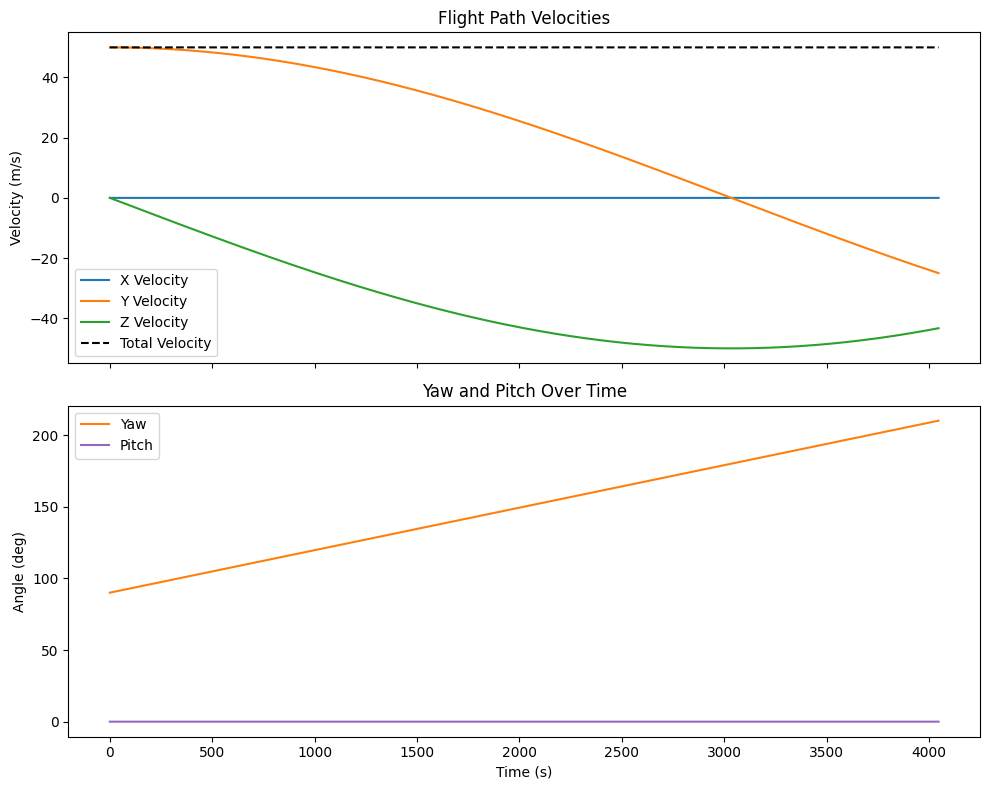

In [ ]:
pmf = pre_made_flightpaths()

const_range_el_data, ref_pos = pmf.const_range_el(slant_range=100000, el=15, az_i=0, az_f=120, true_vel=50, orientation='cw', banking='no')

plotter = plotters(const_range_el_data, ref_pos)
plotter.plot_path_ecef(filepath=None)
#plotter.plot_path_on_globe(filepath=None)
csv_saver.csv_saver(const_range_el_data, filename="interpolated_path_const_range_el.csv", directory="Downloads")